In [ ]:
import os
import cv2
import numpy as np
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom, RandomContrast, RandomCrop, Input
from tensorflow.keras import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import tensorflow as tf
from tensorflow.keras import regularizers
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("artyomkolas/3-kinds-of-pneumonia")

print("Path to dataset files:", path)

Using Colab cache for faster access to the '3-kinds-of-pneumonia' dataset.
Path to dataset files: /kaggle/input/3-kinds-of-pneumonia


In [ ]:
# Dataset path
base_path = os.path.join(path, "Curated X-Ray Dataset")
classes = ["Normal","Pneumonia-Bacterial"]
IMG_SIZE = (224, 224)

def load_dataset(base_dir, classes, limit_per_class=None):
    X, y = [], []
    for idx, class_name in enumerate(classes):
        class_path = os.path.join(base_dir, class_name)
        if not os.path.exists(class_path):
            print(f"Class path not found: {class_path}")
            continue

        files = [f for f in os.listdir(class_path) if f.lower().endswith((".jpg", ".jpeg", ".png"))]
        np.random.shuffle(files)  # randomize

        # limit how many images to load (if specified)
        if limit_per_class:
            files = files[:limit_per_class]

        for file in files:
            img_path = os.path.join(class_path, file)
            img = cv2.imread(img_path)
            if img is not None:
                img = cv2.resize(img, IMG_SIZE)
                X.append(img)
                y.append(idx)

    X = np.array(X, dtype=np.float32) / 255.0
    y = np.array(y)
    return X, y


# Example: load only 500 images per class
X, y = load_dataset(base_path, classes, limit_per_class=500)
print(f"Loaded dataset: {X.shape}, {y.shape}")

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")


Loaded dataset: (1000, 224, 224, 3), (1000,)
Train: (800, 224, 224, 3), Val: (100, 224, 224, 3), Test: (100, 224, 224, 3)


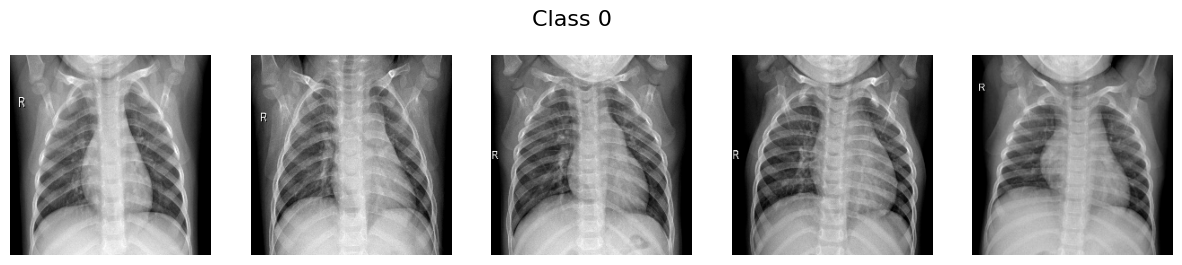

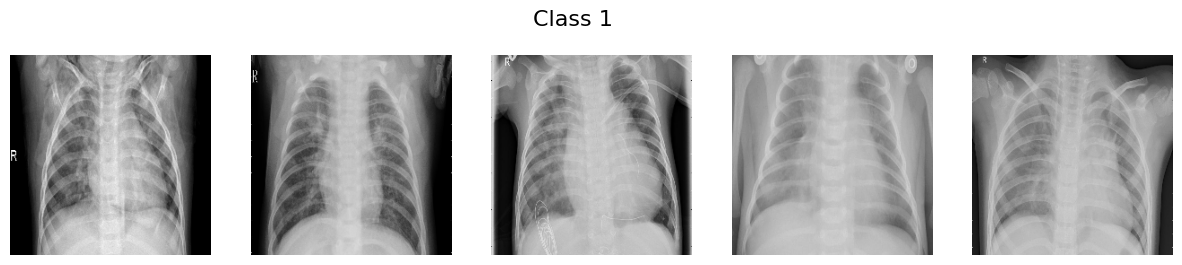

In [ ]:
num_images = 5

classes = [0, 1]  # 0=Normal, 1=Pneumonia-Bacterial

for cls in classes:
    idxs = np.where(y_train == cls)[0][:num_images]  # first 5 images of the class
    fig, axes = plt.subplots(1, num_images, figsize=(15,3))
    fig.suptitle(f"Class {cls}", fontsize=16)

    for j, ax in enumerate(axes):
        ax.imshow(X_train[idxs[j]])
        ax.axis('off')

    plt.show()





In [ ]:
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = dict(enumerate(class_weights))
print("Class weights:", class_weights)

Class weights: {0: np.float64(1.0), 1: np.float64(1.0)}


In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

base_model = MobileNetV2(input_shape=(224,224,3), include_top=False, weights='imagenet')
base_model.trainable = False  # freeze base

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.2)(x)
preds = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=preds)
model.compile(optimizer=Adam(1e-5), loss='binary_crossentropy', metrics=['accuracy'])


In [ ]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
]

history = model.fit(
    X_train,y_train,
    validation_data=(X_val,y_val),
    epochs=10,
    class_weight=class_weights,
    callbacks=callbacks
)


# Evaluate on test set
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc*100:.2f}%")

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 18s 358ms/step - accuracy: 0.5180 - loss: 0.8192 - val_accuracy: 0.4900 - val_loss: 0.7847
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.5524 - loss: 0.7273 - val_accuracy: 0.5200 - val_loss: 0.7134
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.6206 - loss: 0.6797 - val_accuracy: 0.6200 - val_loss: 0.6606
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.6864 - loss: 0.6209 - val_accuracy: 0.7000 - val_loss: 0.6181
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.7312 - loss: 0.5723 - val_accuracy: 0.7800 - val_loss: 0.5795
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.7493 - loss: 0.5348 - val_accuracy: 0.7900 - val_loss: 0.5452
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.7706 - loss: 0.5083 - val_accuracy: 0.8000 - val_loss: 0.5141
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.8092 - loss: 0.4737 - val_accuracy: 0.8200 -

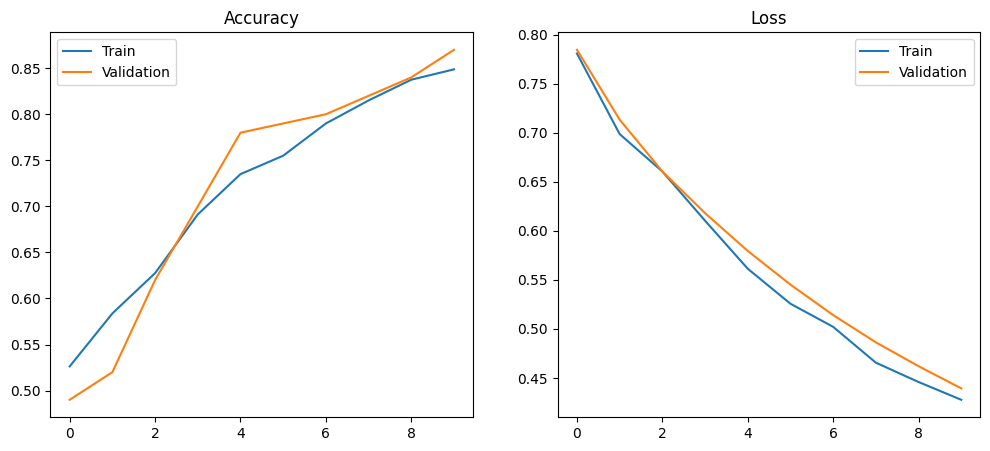

In [ ]:
# Optional: plot accuracy and loss
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Accuracy')
plt.legend()
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Loss')
plt.legend()
plt.show()

In [ ]:
import cv2
import numpy as np
from tensorflow.keras.models import load_model

# Path to the image you want to predict
img_path = "/kaggle/input/3-kinds-of-pneumonia/Curated X-Ray Dataset/Normal/Normal (1).jpg"  # replace with your image path

# Load image
img = cv2.imread(img_path)
img = cv2.resize(img, (224,224))
img = img.astype(np.float32) / 255.0  # same preprocessing as training
img = np.expand_dims(img, axis=0)  # add batch dimension

pred = model.predict(img)

# For binary classification
if pred[0][0] > 0.5:
    print("Predicted class: Pneumonia-Bacterial")
else:
    print("Predicted class: Normal")



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Predicted class: Normal
